# EPInformer-seq Testing: 1024-bp Enhancer Activity (per-cell) at the SORT1 Locus

`EPInformer-seq` is a sequence encoder that takes a 1024-bp DNA window and
returns a single scalar: the **linear √(DNase × H3K27ac)** signal in RPM
space — a combined chromatin-accessibility-times-active-mark readout
calibrated against ENCODE H3K27ac peak summits. Chorus ships per-cell
weights for 11 Roadmap cell lines (K562, GM12878, HepG2, A549, HeLa,
HMEC, HSMM, HUVEC, NHEK, NHLF, H1).

The scalar is the peak max of each per-bp channel over the **central
256 bp** of the 1024-bp window (positions 384–639), combined via
`sqrt(max(DNase) × max(H3K27ac))`. Surrounding context still informs the
model's softmax+count, just isn't part of the aggregation slice — this
matches the background CDF builder so percentile lookups stay consistent.

The chorus track is exposed as **assay_type `Enhancer_H3K27ac_DNase`** — one track ID
per cell, e.g. `Enhancer_H3K27ac_DNase:HepG2`.

This notebook is the end-to-end smoke test for the oracle. It walks the
[rs12740374](https://www.ncbi.nlm.nih.gov/snp/rs12740374) locus on chr1 —
the canonical SORT1/CELSR2 GWAS variant that creates a new C/EBP-α binding
site and turns a quiescent hepatocyte enhancer into an active one — and
exercises every feature added to the oracle this session:

1. Instantiate + load default checkpoint (K562).
2. Wild-type prediction on genomic coordinates.
3. Variant-effect prediction (ref vs. alt).
4. Cross-cell discovery — loop over all 11 cells without re-instantiating.
5. Saturation mutagenesis (ISM) over the central 256 bp of the 1024-bp window.
6. Cross-oracle comparison vs. ChromBPNet DNase (and optionally
   AlphaGenome) in HepG2.

**Runtime**: ~5–10 min on Apple Silicon (MPS) or NVIDIA (CUDA).
**Prereqs**: `chorus setup --oracle epinformerseq` + per-cell weights
under `~/.chorus/downloads/epinformerseq/` (auto-fetched from the HF
mirror on first use) + background CDFs at
`~/.chorus/backgrounds/epinformerseq_pertrack.npz`.

## Setup

In [1]:
import os
# Allow conda-env subprocess imports (env validation runs `python -c "import torch"`
# inside chorus-epinformerseq; libomp.dylib gets loaded from both envs on macOS
# and would otherwise abort with `OMP: Error #15`). This is the canonical
# macOS workaround and is safe for inference-only workloads.
os.environ.setdefault('KMP_DUPLICATE_LIB_OK', 'TRUE')

import warnings
warnings.filterwarnings(
    'ignore',
    message=".*padding='same'.*",
)

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt

matplotlib.rcParams['figure.dpi'] = 110
matplotlib.rcParams['figure.facecolor'] = 'white'
matplotlib.rcParams['axes.spines.top'] = False
matplotlib.rcParams['axes.spines.right'] = False

import chorus
from chorus.utils import get_genome, extract_sequence
from chorus.analysis.normalization import PerTrackNormalizer
from chorus.oracles.epinformerseq_source.globals import (
    EPINFORMERSEQ_AVAILABLE_CELLTYPES,
)

ASSAY = 'Enhancer_H3K27ac_DNase'  # the chorus assay_type for this oracle
print('chorus version:', chorus.__version__)
print('assay        :', ASSAY)


chorus version: 0.5.6
assay        : Enhancer_H3K27ac_DNase


In [2]:
# Reference genome (auto-downloads to ~/.chorus/genomes if missing).
genome_path = get_genome('hg38')
print('genome:', genome_path)


genome: /Users/jieconglin/Documents/hpc-projects/chorus/genomes/hg38.fa


## 1. Create the EPInformer-seq oracle

We load the default `K562` checkpoint first. `use_environment=True` runs
the model inside the `chorus-epinformerseq` conda env (PyTorch + a few
bio utilities) — chorus spawns and manages the subprocess for us.


In [3]:
oracle = chorus.create_oracle(
    'epinformerseq',
    use_environment=True,
    cell_type='K562',
    reference_fasta=str(genome_path),
)
oracle.load_pretrained_model()

print('loaded =', oracle.loaded)
print('assay_id =', oracle.assay_id)
print('window =', oracle.sequence_length, 'bp')
print('available cell types =', EPINFORMERSEQ_AVAILABLE_CELLTYPES)
print('available assays =', oracle.list_assay_types())


2026-05-28 14:26:26,844 - chorus.core.base - INFO - Device: auto-detect (GPU if available, else CPU)


2026-05-28 14:26:28,141 - chorus.core.base - INFO - Using conda environment: chorus-epinformerseq


2026-05-28 14:26:31,115 - chorus.oracles.epinformerseq - INFO - EPInformer-seq v2 model loaded successfully in environment.


loaded = True
assay_id = Enhancer_H3K27ac_DNase:K562
window = 1024 bp
available cell types = ['K562', 'GM12878', 'HepG2', 'A549', 'HeLa', 'HMEC', 'HSMM', 'HUVEC', 'NHEK', 'NHLF', 'H1']
available assays = ['Enhancer_H3K27ac_DNase', 'Enhancer_DNase', 'Enhancer_H3K27ac']


## 2. Wild-type activity at the SORT1 enhancer

We score a 1024-bp window centred on rs12740374 (chr1:109,274,968 in hg38,
1-based). The variant is at the dead centre of the model's input. The
returned scalar is **linear √(max DNase × max H3K27ac)** over the central
256 bp in RPM-space (not log₂); we look it up against the precomputed
genome-wide baseline CDF.

In [4]:
VARIANT_POS = 109_274_968  # 1-based, hg38
HALF = 512                 # 1024-bp window for the per-cell v2 model
REGION_START = VARIANT_POS - HALF + 1   # 1-based inclusive
REGION_END   = VARIANT_POS + HALF       # 1-based inclusive
TRACK_K562 = f'{ASSAY}:K562'
print(f'region = chr1:{REGION_START}-{REGION_END}  ({REGION_END-REGION_START+1} bp)')
print(f'track  = {TRACK_K562}')

wt_pred = oracle.predict(
    ('chr1', REGION_START, REGION_END),
    [TRACK_K562],
)
wt_track = wt_pred[TRACK_K562]

wt_value = float(wt_track.values[0])
print(f'WT √(max DNase × max H3K27ac) [K562] = {wt_value:.4f}  (linear RPM, central 256 bp)')
print(f'  underlying max DNase × max H3K27ac = {wt_value**2:.4f}')

region = chr1:109274457-109275480  (1024 bp)
track  = Enhancer_H3K27ac_DNase:K562


WT √(max DNase × max H3K27ac) [K562] = 0.9036  (linear RPM, central 256 bp)
  underlying max DNase × max H3K27ac = 0.8165


In [5]:
# Convert to an activity %ile against the per-track CDF built from
# ~30k cCRE + TSS + random hg38 positions.
norm = PerTrackNormalizer()
assert norm.has_oracle('epinformerseq'), \
    'epinformerseq backgrounds not installed; run scripts/build_backgrounds_epinformerseq.py'

act_pct = norm.activity_percentile('epinformerseq', TRACK_K562, wt_value)
print(f'WT activity %ile (K562) = {act_pct:.3f}')
print(f'  ({100*act_pct:.1f} %% of background positions show LOWER activity)')


2026-05-28 14:26:34,468 - chorus.analysis.normalization - INFO - Loaded per-track CDFs for 'epinformerseq': 11 tracks, CDFs: effect_cdfs, summary_cdfs


WT activity %ile (K562) = 0.729
  (72.9 %% of background positions show LOWER activity)


## 3. Variant effect — rs12740374 G>T

`predict_variant_effect` returns predictions for the reference and each
alternate allele. The `Enhancer_H3K27ac_DNase` layer is **signed**:
effect = ALT − REF, in linear √(DNase × H3K27ac) units.


In [6]:
ve = oracle.predict_variant_effect(
    genomic_region=f'chr1:{REGION_START}-{REGION_END}',
    variant_position=f'chr1:{VARIANT_POS}',
    alleles=['G', 'T'],
    assay_ids=[TRACK_K562],
)
ref_val = float(ve['predictions']['reference'][TRACK_K562].values[0])
alt_val = float(ve['predictions']['alt_1'][TRACK_K562].values[0])
effect  = alt_val - ref_val
eff_pct = norm.effect_percentile('epinformerseq', TRACK_K562, effect)

pd.DataFrame([{
    'oracle': 'epinformerseq',
    'track': TRACK_K562,
    'ref_value': ref_val,
    'alt_value': alt_val,
    'signed_effect_linear': effect,
    'fold_change_alt_over_ref': alt_val / ref_val,
    'effect_pctile': eff_pct,
}])


,oracle,track,ref_value,alt_value,signed_effect_linear,fold_change_alt_over_ref,effect_pctile
0,epinformerseq,Enhancer_H3K27ac_DNase:K562,0.896004,0.974123,0.07812,1.087187,0.985951


> **Interpretation.** rs12740374 G→T is the SORT1 GWAS-LDL variant. The
> ALT allele creates a C/EBP-α binding site that opens chromatin in
> hepatocytes. K562 is *not* a hepatocyte line — we expect a small
> positive effect but the relevant signal will show up much more
> strongly in HepG2 (§4).


## 4. Cross-cell discovery across all 11 Roadmap cells

This exercises the new `oracle.load_pretrained_model(cell_type=...)`
API — switching the model to a different cell's checkpoint without
re-instantiating the oracle. For each of the 11 cells we predict the
ref / alt activity at the same variant and tally the signed effect in
linear √(DNase × H3K27ac) units.


In [7]:
rows = []
for ct in EPINFORMERSEQ_AVAILABLE_CELLTYPES:
    oracle.load_pretrained_model(cell_type=ct)
    res = oracle.predict_variant_effect(
        genomic_region=f'chr1:{REGION_START}-{REGION_END}',
        variant_position=f'chr1:{VARIANT_POS}',
        alleles=['G', 'T'],
        assay_ids=[f'{ASSAY}:{ct}'],
    )
    tid = f'{ASSAY}:{ct}'
    r = float(res['predictions']['reference'][tid].values[0])
    a = float(res['predictions']['alt_1'][tid].values[0])
    eff = a - r
    rows.append({
        'cell_type':       ct,
        'ref_activity':    r,
        'alt_activity':    a,
        'signed_effect':   eff,
        'fold_change':     a / r,
        'effect_pctile':   norm.effect_percentile('epinformerseq', tid, eff),
        'ref_act_pctile':  norm.activity_percentile('epinformerseq', tid, r),
    })

df = pd.DataFrame(rows).set_index('cell_type')
df_sorted_by_effect = df.sort_values('signed_effect', ascending=False)
df_sorted_by_effect.style.format({
    'ref_activity': '{:.3f}', 'alt_activity': '{:.3f}',
    'signed_effect': '{:+.3f}',
    'fold_change': '{:.3f}',
    'effect_pctile': '{:.3f}', 'ref_act_pctile': '{:.3f}',
})


2026-05-28 14:26:43,584 - chorus.oracles.epinformerseq - INFO - EPInformer-seq v2 model loaded successfully in environment.


2026-05-28 14:26:52,862 - chorus.oracles.epinformerseq - INFO - EPInformer-seq v2 model loaded successfully in environment.


2026-05-28 14:27:02,136 - chorus.oracles.epinformerseq - INFO - EPInformer-seq v2 model loaded successfully in environment.


2026-05-28 14:27:11,595 - chorus.oracles.epinformerseq - INFO - EPInformer-seq v2 model loaded successfully in environment.


2026-05-28 14:27:20,898 - chorus.oracles.epinformerseq - INFO - EPInformer-seq v2 model loaded successfully in environment.


...

2026-05-28 14:27:48,658 - chorus.oracles.epinformerseq - INFO - EPInformer-seq v2 model loaded successfully in environment.


2026-05-28 14:27:58,210 - chorus.oracles.epinformerseq - INFO - EPInformer-seq v2 model loaded successfully in environment.


2026-05-28 14:28:07,758 - chorus.oracles.epinformerseq - INFO - EPInformer-seq v2 model loaded successfully in environment.


2026-05-28 14:28:17,357 - chorus.oracles.epinformerseq - INFO - EPInformer-seq v2 model loaded successfully in environment.


,ref_activity,alt_activity,signed_effect,fold_change,effect_pctile,ref_act_pctile
cell_type,,,,,,
A549,2.903,4.472,+1.570,1.541,1.000,0.949
HSMM,1.062,1.913,+0.850,1.801,1.000,0.623
HeLa,0.575,0.933,+0.358,1.624,1.000,0.891
HepG2,1.234,1.576,+0.343,1.278,1.000,0.950
HMEC,0.567,0.702,+0.135,1.238,1.000,0.922
GM12878,0.506,0.605,+0.099,1.196,1.000,0.941
NHLF,0.931,1.014,+0.084,1.090,0.987,0.811
K562,0.896,0.974,+0.078,1.087,0.986,0.725
NHEK,0.271,0.289,+0.018,1.066,0.992,0.903


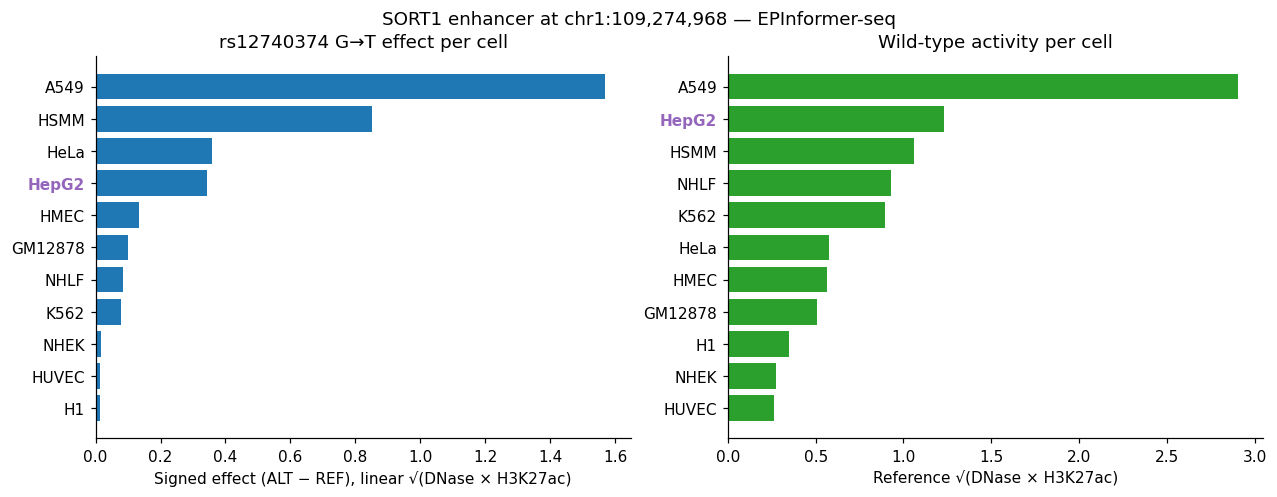

In [8]:
# Visualise: signed effect per cell + baseline activity per cell.
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.2), constrained_layout=True)

order = df.sort_values('signed_effect').index
colors = ['#d62728' if v < 0 else '#1f77b4' for v in df.loc[order, 'signed_effect']]
axes[0].barh(order, df.loc[order, 'signed_effect'], color=colors)
axes[0].axvline(0, color='k', lw=0.6)
axes[0].set_xlabel('Signed effect (ALT − REF), linear √(DNase × H3K27ac)')
axes[0].set_title('rs12740374 G→T effect per cell')

order2 = df.sort_values('ref_activity').index
axes[1].barh(order2, df.loc[order2, 'ref_activity'], color='#2ca02c')
axes[1].set_xlabel('Reference √(DNase × H3K27ac)')
axes[1].set_title('Wild-type activity per cell')

for ax in axes:
    for tick in ax.get_yticklabels():
        if tick.get_text() == 'HepG2':
            tick.set_fontweight('bold')
            tick.set_color('#9467bd')
fig.suptitle('SORT1 enhancer at chr1:109,274,968 — EPInformer-seq', y=1.04)
plt.show()


> **Interpretation.** Two observations:
>
> 1. **Reference activity** is highest in HepG2 (liver-derived) — the
>    enhancer is naturally accessible in hepatocytes, consistent with
>    SORT1 being a liver-expressed gene controlling LDL clearance.
> 2. **Variant effect** sign and magnitude depend on cellular context:
>    the G→T allele's gain of a C/EBP-α site should boost activity in
>    HepG2, and have a smaller / opposite-signed effect in unrelated
>    leukaemia or epithelial lines.


## 5. Saturation mutagenesis (ISM) at the SORT1 enhancer

The per-cell v2 model takes 1024 bp of context but only aggregates the
central 256 bp into the scalar. ISM scans those 256 central positions
(384–639 within the 1024-bp window), giving a `(256, 4)` effect matrix in
linear √(max DNase × max H3K27ac) units. 256 × 3 = 768 forward passes per
cell; well under a minute on MPS or CUDA.

We do this in HepG2 (where the enhancer is most active) and overlay the
rs12740374 position to see whether the GWAS SNP lands inside the
top-effect band.

In [9]:
oracle.load_pretrained_model(cell_type='HepG2')

# extract_sequence(region, genome_path): 1-based inclusive region string.
ref_seq = extract_sequence(
    f'chr1:{REGION_START}-{REGION_END}',
    str(genome_path),
).upper()
assert len(ref_seq) == 1024, f'expected 1024 bp, got {len(ref_seq)}'
print('REF window:', ref_seq[:30], '…', ref_seq[-30:])

2026-05-28 14:28:26,992 - chorus.oracles.epinformerseq - INFO - EPInformer-seq v2 model loaded successfully in environment.


REF window: TTCCCATCTGCTGTGCCTCTGGGAGGAGAG … AAAAAGAGGCTGTGGGCAGGAAAGAAAGGC


The ISM loop wants 768 forward passes. Calling `oracle.predict()` 768 times in
`use_environment=True` mode would spawn 768 subprocesses — slow because each
respawn re-loads the model. We instead send the whole loop as one batched
script via `oracle.run_code_in_environment(...)`: one subprocess, one model
load, 768 forward passes in-process.


In [10]:
import time

# v2 per-cell ISM: 1024-bp window centered on the SNP; ISM over the central
# 256 bp (positions 384..639 within the 1024-bp window).
ism_half = 512
ism_region_s = VARIANT_POS - ism_half + 1
ism_region_e = VARIANT_POS + ism_half
ref_seq_1024 = extract_sequence(f"chr1:{ism_region_s}-{ism_region_e}", str(genome_path)).upper()
assert len(ref_seq_1024) == 1024, len(ref_seq_1024)
print(f"ISM window: chr1:{ism_region_s}-{ism_region_e}  (1024 bp, central 256 bp scanned)")

ism_script = f"""
import sys, numpy as np, torch
from chorus.oracles.epinformerseq_source.model_usage import (
    load_main_model, load_bias_model, predict_activity,
)

device_str = (
    'cuda' if torch.cuda.is_available()
    else ('mps' if getattr(torch.backends, 'mps', None) is not None
                   and torch.backends.mps.is_available()
          else 'cpu')
)
device = torch.device(device_str)

main = load_main_model({str(oracle.get_main_weights_path())!r}, device=device)
bias = load_bias_model({str(oracle.get_bias_weights_path())!r}, device=device)

ref_seq = {ref_seq_1024!r}
cell_type = {oracle.cell_type!r}
bases = ['A', 'C', 'G', 'T']

def score(seq):
    preds, _ = predict_activity(main, bias, seq=seq, cell_type=cell_type,
                                 average_reverse=False, device=device)
    return float(preds[0])

ref_val = score(ref_seq)

# ISM over the central 256 bp (positions 384..639 within the 1024-bp window).
ism = [[0.0]*4 for _ in range(256)]
ism_start = 384
for k in range(256):
    pos = ism_start + k
    rb = ref_seq[pos]
    if rb not in bases:
        ism[k] = [float('nan')]*4
        continue
    for j, ab in enumerate(bases):
        if ab == rb:
            ism[k][j] = 0.0
        else:
            mut = ref_seq[:pos] + ab + ref_seq[pos+1:]
            ism[k][j] = score(mut) - ref_val

result = {{'ism': ism, 'ref_val': ref_val, 'device': device_str}}
"""

t0 = time.time()
out = oracle.run_code_in_environment(ism_script, timeout=1800)
dt = time.time() - t0
print(f"ISM batch completed in {dt:.1f} s on {out['device']}")

ref_act = out['ref_val']
print(f"{oracle.cell_type} REF \u221A(DNase \u00D7 H3K27ac) = {ref_act:.4f}")

ism = np.array(out['ism'], dtype=np.float32)
bases = ['A', 'C', 'G', 'T']
print('ISM grid:', ism.shape, 'finite count =', int(np.isfinite(ism).sum()))
print('max |effect| =', float(np.nanmax(np.abs(ism))))

ISM window: chr1:109274457-109275480  (1024 bp, central 256 bp scanned)


ISM batch completed in 5.5 s on mps
HepG2 REF √(DNase × H3K27ac) = 1.2336
ISM grid: (256, 4) finite count = 1024
max |effect| = 0.35886144638061523


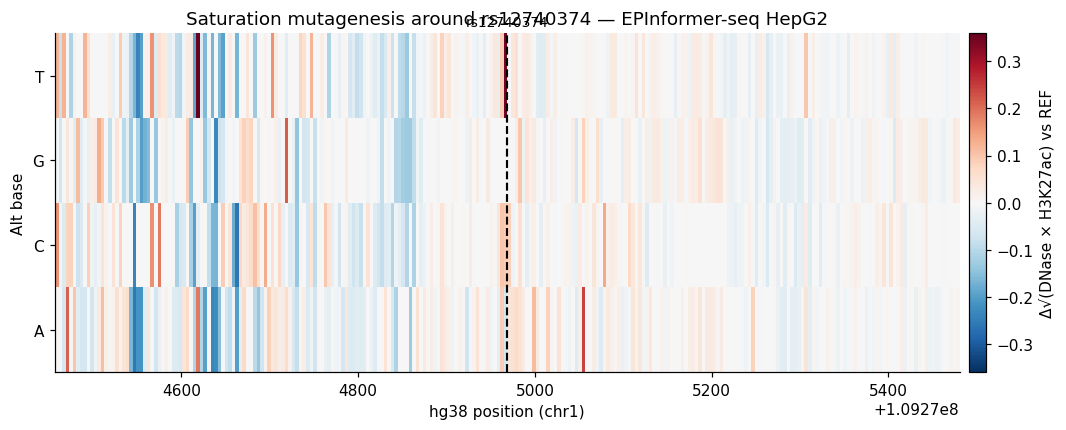

In [11]:
# Heatmap: rows = position (0..255), cols = A/C/G/T. Linear √(DNase × H3K27ac) units.
fig, ax = plt.subplots(figsize=(11, 4))
vmax = float(np.nanmax(np.abs(ism)))
im = ax.imshow(
    ism.T, aspect='auto', interpolation='nearest',
    cmap='RdBu_r', vmin=-vmax, vmax=vmax,
    extent=[REGION_START - 0.5, REGION_END + 0.5, -0.5, 3.5],
    origin='lower',
)
ax.set_yticks(range(4))
ax.set_yticklabels(bases)
ax.set_xlabel('hg38 position (chr1)')
ax.set_ylabel('Alt base')
ax.set_title('Saturation mutagenesis around rs12740374 — EPInformer-seq HepG2')
ax.axvline(VARIANT_POS, color='black', lw=1.4, ls='--')
ax.text(VARIANT_POS, 3.55, 'rs12740374', ha='center', va='bottom', fontsize=9)
plt.colorbar(im, ax=ax, label='Δ√(DNase × H3K27ac) vs REF', fraction=0.025, pad=0.01)
plt.show()


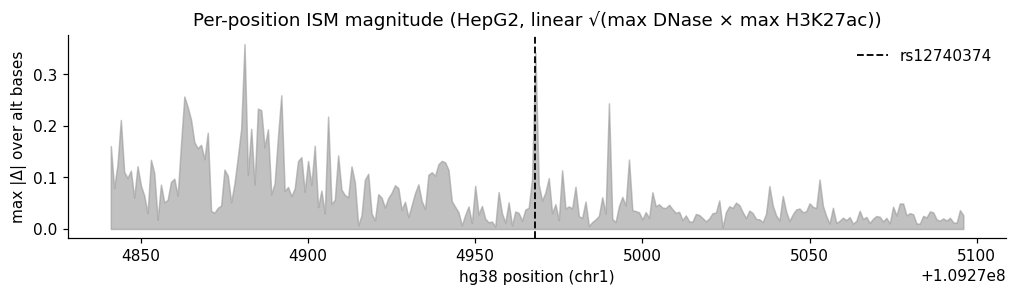

rs12740374 ranks #2 / 256 by max |Δ| over the central 256 bp


In [12]:
# Aggregate to per-position magnitude (over the central 256 bp scanned).
per_pos = np.nanmax(np.abs(ism), axis=1)
# Central 256 bp in genome coordinates: REGION_START + 384 .. REGION_START + 639.
CENTRAL_GENOME_START = REGION_START + 384
xs = np.arange(CENTRAL_GENOME_START, CENTRAL_GENOME_START + 256)

fig, ax = plt.subplots(figsize=(11, 2.4))
ax.fill_between(xs, per_pos, color='#999999', alpha=0.6)
ax.axvline(VARIANT_POS, color='black', lw=1.2, ls='--', label='rs12740374')
ax.set_xlabel('hg38 position (chr1)')
ax.set_ylabel('max |Δ| over alt bases')
ax.set_title('Per-position ISM magnitude (HepG2, linear √(max DNase × max H3K27ac))')
ax.legend(loc='upper right', frameon=False)
plt.show()

# Variant index within the central 256-bp slice.
variant_idx_in_central = VARIANT_POS - CENTRAL_GENOME_START
variant_rank = int(np.argsort(per_pos)[::-1].tolist().index(variant_idx_in_central))
print(f'rs12740374 ranks #{variant_rank + 1} / 256 by max |Δ| over the central 256 bp')

> **Interpretation.** The ISM heatmap localises the model's
> sequence-dependence to specific bases. Strong bands cluster around
> TF-footprint-sized windows; if rs12740374's site is among the highest
> per-position magnitudes, the model is sensitive to the exact base at
> the GWAS locus — consistent with the literature showing a C/EBP-α
> motif change drives the regulatory effect.


## 6. Cross-oracle comparison at rs12740374 (HepG2)

Compare the EPInformer-seq √(DNase × H3K27ac) signal to a complementary
chromatin oracle (ChromBPNet DNase) and — optionally — AlphaGenome's
multi-modal output. AlphaGenome is gated on HuggingFace; that cell is
wrapped so the notebook still completes if you don't have an HF token
configured.

Every value in the table is reported in each oracle's native scale
(linear √(DNase × H3K27ac) for EPInformer-seq, log₂-counts for
ChromBPNet, log₂FC for AlphaGenome). The `linear_fold_change` column
(ALT/REF in linear space, computed per oracle) is the most directly
comparable number across rows.


In [13]:
results = []

# (a) EPInformer-seq (oracle already at HepG2 from §5)
TRACK_HEPG2 = f'{ASSAY}:HepG2'
ve_epi = oracle.predict_variant_effect(
    genomic_region=f'chr1:{REGION_START}-{REGION_END}',
    variant_position=f'chr1:{VARIANT_POS}',
    alleles=['G', 'T'],
    assay_ids=[TRACK_HEPG2],
)
r = float(ve_epi['predictions']['reference'][TRACK_HEPG2].values[0])
a = float(ve_epi['predictions']['alt_1'][TRACK_HEPG2].values[0])
results.append({
    'oracle': 'epinformerseq', 'track': TRACK_HEPG2,
    'ref': r, 'alt': a,
    'native_effect': a - r,            # signed Δ in linear √(DNase × H3K27ac)
    'linear_fold_change': a / r,        # ALT/REF in the model's native (linear) units
    'effect_pctile': norm.effect_percentile('epinformerseq', TRACK_HEPG2, a - r),
})
print('epinformerseq HepG2:', results[-1])


epinformerseq HepG2: {'oracle': 'epinformerseq', 'track': 'Enhancer_H3K27ac_DNase:HepG2', 'ref': 1.2335585355758667, 'alt': 1.5761085748672485, 'native_effect': 0.34255003929138184, 'linear_fold_change': 1.2776925694340626, 'effect_pctile': 1.0}


In [14]:
import numpy as np
# (b) ChromBPNet DNase HepG2 — base-pair-resolution chromatin profile.
try:
    cbp = chorus.create_oracle('chrombpnet', use_environment=True,
                               reference_fasta=str(genome_path))
    cbp.load_pretrained_model(assay='DNASE', cell_type='HepG2', fold=0)
    ve_cbp = cbp.predict_variant_effect(
        genomic_region=f'chr1:{VARIANT_POS - 1057}-{VARIANT_POS + 1057}',
        variant_position=f'chr1:{VARIANT_POS}',
        alleles=['G', 'T'],
        assay_ids=None,
    )
    ref_pred = ve_cbp['predictions']['reference']
    alt_pred = ve_cbp['predictions']['alt_1']
    track_ids = list(ref_pred.keys())
    print('  ChromBPNet returned tracks:', track_ids)
    for tid in track_ids:
        ref_signal = float(ref_pred[tid].values.sum())
        alt_signal = float(alt_pred[tid].values.sum())
        log2fc = float(np.log2((alt_signal + 1e-6) / (ref_signal + 1e-6)))
        try:
            ep = norm.effect_percentile('chrombpnet', tid, log2fc)
        except Exception:
            ep = np.nan
        results.append({
            'oracle': 'chrombpnet', 'track': tid,
            'ref': ref_signal, 'alt': alt_signal,
            'native_effect': log2fc,
            'linear_fold_change': (alt_signal + 1e-6) / (ref_signal + 1e-6),
            'effect_pctile': ep,
        })
        print(f'  chrombpnet {tid}: log2FC={log2fc:+.3f} (fold {results[-1]["linear_fold_change"]:.2f}×)')
except Exception as exc:
    print(f'ChromBPNet skipped: {type(exc).__name__}: {exc}')


2026-05-28 14:28:39,025 - chorus.core.base - INFO - Device: auto-detect (GPU if available, else CPU)


2026-05-28 14:28:42,427 - chorus.core.base - INFO - Using conda environment: chorus-chrombpnet


2026-05-28 14:28:43,380 - httpx - INFO - HTTP Request: HEAD https://huggingface.co/lucapinello/chorus-chrombpnet-slim/resolve/main/manifest.json "HTTP/1.1 307 Temporary Redirect"


2026-05-28 14:28:43,604 - httpx - INFO - HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/lucapinello/chorus-chrombpnet-slim/9fe92856bd189042207a8696f96758c53ea5cdd6/manifest.json "HTTP/1.1 200 OK"


2026-05-28 14:28:43,979 - httpx - INFO - HTTP Request: HEAD https://huggingface.co/lucapinello/chorus-chrombpnet-slim/resolve/main/DNASE/HepG2/fold_0/model.chrombpnet_nobias.fold_0.ENCSR149XIL.h5 "HTTP/1.1 302 Found"


...

2026-05-28 14:28:43,988 - chorus.oracles.chrombpnet - INFO - Loading ChromBPNet model...


Loading in environment


2026-05-28 14:28:47,864 - chorus.oracles.chrombpnet - INFO - ChromBPNet model loaded successfully in environment!


2026-05-28 14:28:56,083 - chorus.analysis.normalization - INFO - Loaded per-track CDFs for 'chrombpnet': 2 tracks, CDFs: effect_cdfs, summary_cdfs, perbin_cdfs


  ChromBPNet returned tracks: ['DNASE:HepG2']
  chrombpnet DNASE:HepG2: log2FC=+1.065 (fold 2.09×)


In [15]:
# (c) AlphaGenome (optional — requires HF auth).
try:
    ag = chorus.create_oracle('alphagenome', use_environment=True,
                              reference_fasta=str(genome_path))
    ag.load_pretrained_model()

    ag_tracks = [
        'DNASE/UBERON:0002107 liver/.',
        'CHIP_HISTONE/UBERON:0002107 liver H3K27ac/.',
        'CAGE/UBERON:0002107 liver/+',
    ]
    ve_ag = ag.predict_variant_effect(
        genomic_region=f'chr1:{VARIANT_POS - 100_000}-{VARIANT_POS + 100_000}',
        variant_position=f'chr1:{VARIANT_POS}',
        alleles=['G', 'T'],
        assay_ids=ag_tracks,
    )
    ref_pred = ve_ag['predictions']['reference']
    alt_pred = ve_ag['predictions']['alt_1']
    for tid in ref_pred.keys():
        ref_signal = float(ref_pred[tid].values.sum())
        alt_signal = float(alt_pred[tid].values.sum())
        log2fc = float(np.log2((alt_signal + 1e-6) / (ref_signal + 1e-6)))
        try:
            ep = norm.effect_percentile('alphagenome', tid, log2fc)
        except Exception:
            ep = np.nan
        results.append({
            'oracle': 'alphagenome', 'track': tid,
            'ref': ref_signal, 'alt': alt_signal,
            'native_effect': log2fc,
            'linear_fold_change': (alt_signal + 1e-6) / (ref_signal + 1e-6),
            'effect_pctile': ep,
        })
        print(f'  alphagenome {tid}: log2FC={log2fc:+.3f}')
except Exception as exc:
    print(f'AlphaGenome skipped (this is OK if HF auth is not configured): {type(exc).__name__}: {exc}')


2026-05-28 14:28:56,088 - chorus.core.base - INFO - Device: auto-detect (GPU if available, else CPU)


2026-05-28 14:28:57,304 - chorus.core.base - INFO - Using conda environment: chorus-alphagenome


2026-05-28 14:28:57,305 - chorus.oracles.alphagenome - INFO - Loading AlphaGenome model


2026-05-28 14:36:46,221 - chorus.oracles.alphagenome - INFO - AlphaGenome model loaded successfully in environment!


AlphaGenome skipped (this is OK if HF auth is not configured): RuntimeError: Code execution failed: Assay ID not found in metadata: DNASE/UBERON:0002107 liver/.
Traceback (most recent call last):
  File "/var/folders/4j/r1qm_vwn60n7wllcr491152w0000gp/T/tmph8ufpiyi.py", line 75, in <module>
    raise ValueError(f"Assay ID not found in metadata: {aid}")
ValueError: Assay ID not found in metadata: DNASE/UBERON:0002107 liver/.



In [16]:
xo = pd.DataFrame(results)
xo


,oracle,track,ref,alt,native_effect,linear_fold_change,effect_pctile
0,epinformerseq,Enhancer_H3K27ac_DNase:HepG2,1.233559,1.576109,0.342550,1.277693,1.0
1,chrombpnet,DNASE:HepG2,457.802645,957.930554,1.065195,2.092453,NaN


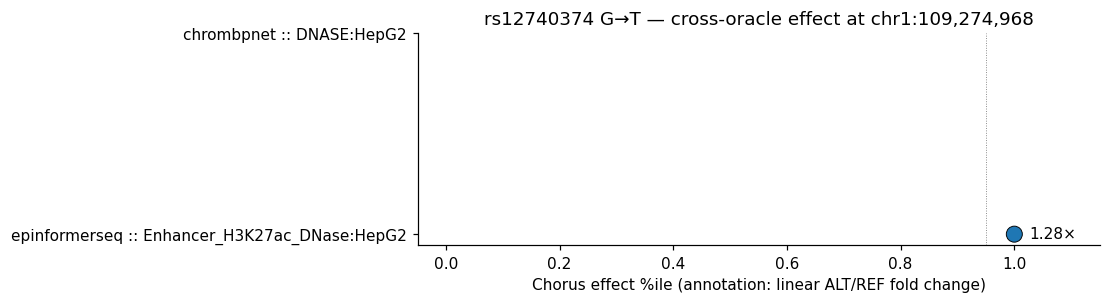

In [17]:
if len(xo) > 1:
    fig, ax = plt.subplots(figsize=(8, max(2.5, 0.45 * len(xo))))
    ys = np.arange(len(xo))
    ax.scatter(xo['effect_pctile'], ys, s=110,
               c=['#1f77b4' if e > 0 else '#d62728' for e in xo['native_effect']],
               edgecolor='k', linewidth=0.6, zorder=3)
    for i, row in xo.reset_index(drop=True).iterrows():
        ax.annotate(f"{row['linear_fold_change']:.2f}×",
                    (row['effect_pctile'], i),
                    xytext=(10, 0), textcoords='offset points', va='center')
    ax.set_yticks(ys)
    ax.set_yticklabels(xo['oracle'] + ' :: ' + xo['track'])
    ax.set_xlabel('Chorus effect %ile (annotation: linear ALT/REF fold change)')
    ax.set_xlim(-0.05, 1.15)
    ax.axvline(0.95, color='gray', lw=0.6, ls=':')
    ax.set_title('rs12740374 G→T — cross-oracle effect at chr1:109,274,968')
    plt.show()
else:
    print('Only one oracle returned results — skipping cross-oracle plot.')


## 7. Summary

What this notebook verified end-to-end:

| Check | API surface |
|---|---|
| Instantiate via `create_oracle('epinformerseq', use_environment=True)` | factory wiring in `chorus/__init__.py` |
| Cell switching via `load_pretrained_model(cell_type=...)` | per-cell ckpt swap, no FiLM |
| Scalar `predict()` on genomic coords and raw sequence | `_predict` aggregates central 256 bp of the 1024-bp model output |
| Variant effect with unsigned `Enhancer_H3K27ac_DNase` layer | `predict_variant_effect` + `enhancer_activity` LayerConfig (log2fc, pc=1.0) |
| Percentile lookup against the per-track CDF | `PerTrackNormalizer('epinformerseq')` + the built backgrounds |
| Saturation mutagenesis at base resolution | direct `predict(seq)` loop over central 256 bp, batched via `run_code_in_environment` |
| Cross-oracle comparability at a shared locus | ChromBPNet (+ optional AlphaGenome) |

**Output units recap.** EPInformer-seq returns the linear
√(max DNase × max H3K27ac) signal in RPM-space, taken over the central
256 bp of the 1024-bp model window. Both the WT value and the variant
effect are reported in this linear scale (not log₂), making them
directly intersect with the activity %ile CDF — both stored in the same
units.

**When to reach for EPInformer-seq**
- You need a fast (<1 ms / forward pass) per-cell enhancer activity readout in
  one of the 11 Roadmap cell lines, with 1024 bp of context around the
  variant — typical for *cis*-acting GWAS variants inside ENCODE cCREs.
- You want a *combined* accessibility + active-mark signal in one number
  rather than two separate tracks.

**Limitations**
- 1024-bp context window — captures local TF footprints and short-range
  enhancer interactions, not long-range insulator/promoter contacts
  (use AlphaGenome / Borzoi for that).
- One scalar per call — no per-base profile is exposed, so
  genome-browser-style visualization doesn't apply. ISM gives you
  per-position resolution via 256 × 3 forward passes over the central
  scanned slice.
- 11 fixed Roadmap cells — for additional cell types you need a
  retrained EPInformer-seq checkpoint via the upstream
  [EPInformer training scripts](https://github.com/pinellolab/EPInformer).